In [19]:
import os
import json
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from enum import Enum
from glob import glob
from pathlib import Path
from typing import List, Dict
import matplotlib.pyplot as plt
from functools import lru_cache
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.document_converter import DocumentConverter, PdfFormatOption
from transformers import AutoTokenizer
from langchain_chroma.vectorstores import Chroma
from src.config import *
from src.retriever import retrieve_context

In [2]:
class ChunkingStrategy(str, Enum):
    STRUCTURE = "structure"
    SENTENCE = "sentence"
    SLIDING = "sliding"
    SEMANTIC = "semantic"
    HYBRID_SECTION_SEMANTIC = "hybrid_section_semantic"
    AUTO = "auto"

for strategy in [
        ChunkingStrategy.STRUCTURE,
        ChunkingStrategy.SLIDING,
        ChunkingStrategy.SEMANTIC,
        ChunkingStrategy.HYBRID_SECTION_SEMANTIC,
    ]:
    db_dir = os.path.join(PDF_DB_DIR, strategy.value)
    db = Chroma(persist_directory=db_dir)
    data = db.get()
    metadatas = data["metadatas"]
    print(f"{strategy.value}: {len(metadatas)} chunks")

2026-02-11 19:52:29,183 - INFO - Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.
2026-02-11 19:52:29,831 - INFO - Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.


structure: 2858 chunks


2026-02-11 19:52:30,178 - INFO - Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.


sliding: 2554 chunks


2026-02-11 19:52:30,956 - INFO - Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.


semantic: 5067 chunks
hybrid_section_semantic: 2851 chunks


In [ ]:
# ===============================
# Generic HF CLS Embedder
# ===============================
class HFCLSEmbedder:
    def __init__(self, model_path: str, device: str = 'cpu'):
        model_path = str(Path(model_path).resolve())
        self.model_path = model_path
        self.device = device
        
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_path,
            local_files_only=True
        )

        self.model = AutoModel.from_pretrained(
            model_path,
            local_files_only=True
        ).to(device)

        self.model.eval()

    def encode_ids(self, input_ids: List[int]) -> np.ndarray:
        with torch.no_grad():

            input_ids = torch.tensor([input_ids]).to(self.device)
            attention_mask = torch.ones_like(input_ids)

            outputs = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            cls_embedding = outputs.last_hidden_state[:, 0]
            cls_embedding = F.normalize(cls_embedding, dim=1)

        return cls_embedding.cpu().numpy()[0]


# ===============================
# Cosine similarity
# ===============================
def cosine_sim(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    
    return float(np.dot(a, b) / denom) if denom > 0 else 0.0

# ===============================
# Load all models ONCE
# ===============================
def load_embedders(models: Dict[str, str]) -> Dict[str, HFCLSEmbedder]:
    embedders = {}

    for name, model_path in models.items():
        print(f"\n🔍 Loading {name} ...")
        embedders[name] = HFCLSEmbedder(model_path)

    return embedders

In [6]:
def extract_full_text_from_doc(doc) -> str:
    """
    Extract full raw text from a Docling document
    preserving logical reading order.
    """

    try:
        text = doc.export_to_text()
        if text and text.strip():
            return text.strip()
    except Exception:
        pass

    # fallback nếu export_to_text lỗi
    try:
        text = doc.export_to_markdown()
        if text and text.strip():
            return text.strip()
    except Exception:
        pass

    # final fallback: iterate through items
    texts = []
    for item, _ in doc.iterate_items():
        if hasattr(item, "text") and item.text:
            texts.append(item.text.strip())

    return "\n\n".join(texts).strip()


In [7]:
# ==========================================
# CONFIG
# ==========================================
MODEL_PATH = "./models/all-MiniLM-L6-v2"

# ==========================================
# 1️⃣ Load document + extract raw text
# ==========================================
pdf_options = PdfPipelineOptions()
pdf_options.do_ocr = False

converter = DocumentConverter(
        format_options={
            InputFormat.PDF: PdfFormatOption(pipeline_options=pdf_options)
        }
    )

embedder = HFCLSEmbedder(MODEL_PATH)
tokenizer = embedder.tokenizer

  0%|          | 0/18 [00:00<?, ?it/s]2026-02-08 21:21:42,336 - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]
2026-02-08 21:21:42,357 - INFO - Going to convert document batch...
2026-02-08 21:21:42,360 - INFO - Initializing pipeline for StandardPdfPipeline with options hash 75463f421d05cb4304e1f714cf00d35d
2026-02-08 21:21:42,371 - INFO - Accelerator device: 'cpu'
2026-02-08 21:21:46,504 - INFO - Accelerator device: 'cpu'
2026-02-08 21:21:59,973 - INFO - Processing document An overview of heart rate variability metrics and norms.pdf
2026-02-08 21:23:59,319 - INFO - Finished converting document An overview of heart rate variability metrics and norms.pdf in 136.98 sec.
2026-02-08 21:23:59,459 - WARNING - Parameter `strict_text` has been deprecated and will be ignored.


<class 'list'>
KeysView({'input_ids': [[1001, 1001, 5493, 2011, 1024, 8183, 11431, 21442, 11285, 1010, 3757, 1997, 2591, 3821, 1010, 3956, 1001, 1001, 8182, 2011, 1024, 10413, 1046, 1012, 6218, 6873, 1010, 2642, 4307, 2118, 1010, 2142, 2163, 22358, 20081, 1010, 17919, 2118, 1010, 2710, 1001, 1001, 1008, 11061, 1024, 5965, 21146, 12494, 5965, 7277, 7377, 12494, 1030, 20917, 4014, 1012, 4012, 1001, 1001, 12233, 2930, 1024, 2023, 3720, 2001, 7864, 2000, 2155, 4200, 1998, 3078, 2729, 1010, 1037, 2930, 1997, 1996, 3485, 28750, 1999, 2270, 2740, 2363, 1024, 2656, 2238, 2418, 3970, 1024, 2340, 2244, 2418, 2405, 1024, 2654, 2244, 2418, 1001, 1001, 11091, 1024, 21146, 12494, 1042, 1998, 18353, 11711, 16545, 1006, 2418, 1007, 2019, 19184, 1997, 2540, 3446, 28436, 12046, 2015, 1998], [17606, 1012, 2392, 1012, 2270, 2740, 1019, 1024, 24398, 1012, 9193, 1024, 2184, 1012, 27908, 2683, 1013, 1042, 14289, 23706, 1012, 2418, 1012, 4002, 17788, 2620, 2405, 1024, 2654, 2244, 2418, 9193, 1024, 2184, 1012,

  6%|▌         | 1/18 [02:37<44:33, 157.27s/it]2026-02-08 21:24:19,613 - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]
2026-02-08 21:24:19,691 - INFO - Going to convert document batch...
2026-02-08 21:24:19,695 - INFO - Processing document Doing What Matters in Times of Stress.pdf
2026-02-08 21:32:16,642 - INFO - Finished converting document Doing What Matters in Times of Stress.pdf in 477.03 sec.
2026-02-08 21:32:17,307 - WARNING - Parameter `strict_text` has been deprecated and will be ignored.


<class 'list'>
KeysView({'input_ids': [[1001, 1001, 2725, 2054, 5609, 1999, 2335, 1997, 6911, 1024, 2019, 7203, 5009, 1001, 1001, 2725, 2054, 5609, 1001, 1001, 1999, 2335, 1997, 6911, 1024, 2019, 7203, 5009, 1001, 1001, 2725, 2054, 5609, 1999, 2335, 1997, 6911, 1024, 2019, 7203, 5009, 3175, 4891, 1011, 6227, 1011, 1018, 1011, 2199, 23499, 2487, 1011, 1014, 1006, 4816, 2544, 1007, 3175, 4891, 1011, 6227, 1011, 1018, 1011, 2199, 23499, 2475, 1011, 1021, 1006, 6140, 2544, 1007, 1001, 1001, 1075, 2088, 2740, 3029, 12609, 2070, 2916, 9235, 1012, 2023, 2147, 2003, 2800, 2104, 1996, 5541, 7674, 2012, 18886, 29446, 1011, 2512, 9006, 5017, 13247, 1011, 3745, 11475, 3489, 1017, 1012, 1014, 1045, 3995, 11172, 1006, 10507, 2011, 1011, 13316, 1011, 7842, 1017, 1012, 1014], [1045, 3995, 1025, 16770, 1024, 1013, 1013, 5541, 9006, 16563, 1012, 8917, 1013, 15943, 1013, 2011, 1011, 13316, 1011, 7842, 1013, 1017, 1012, 1014, 1013, 1045, 3995, 1007, 1012, 2104, 1996, 3408, 1997, 2023, 11172, 1010, 2017, 2

 11%|█         | 2/18 [10:43<1:33:32, 350.78s/it]2026-02-08 21:32:25,869 - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]
2026-02-08 21:32:25,879 - INFO - Going to convert document batch...
2026-02-08 21:32:25,884 - INFO - Processing document Everyday Actions For Better Health Who Recommendations.pdf
2026-02-08 21:32:38,352 - INFO - Finished converting document Everyday Actions For Better Health Who Recommendations.pdf in 12.51 sec.
2026-02-08 21:32:38,381 - WARNING - Parameter `strict_text` has been deprecated and will be ignored.


...

<class 'list'>
KeysView({'input_ids': [[1001, 1001, 2040, 12183, 1997, 3465, 1011, 4621, 19388, 2005, 5177, 2740, 1001, 1001, 2040, 12183, 1997, 3465, 1011, 4621, 19388, 2005, 5177, 2740, 1001, 1001, 2040, 12183, 1997, 3465, 1011, 4621, 19388, 2005, 5177, 2740, 3175, 4891, 1011, 6227, 1011, 1018, 1011, 4002, 21486, 2692, 2620, 1011, 1015, 1006, 4816, 2544, 1007, 3175, 4891, 1011, 6227, 1011, 1018, 1011, 4002, 21486, 2692, 2683, 1011, 1022, 1006, 6140, 2544, 1007, 1001, 1001, 1075, 2088, 2740, 3029, 25682, 2070, 2916, 9235, 1012, 2023, 2147, 2003, 2800, 2104, 1996, 5541, 7674, 2012, 18886, 29446, 1011, 2512, 9006, 5017, 13247, 1011, 3745, 11475, 3489, 1017, 1012, 1014, 1045, 3995, 11172, 1006, 10507, 2011, 12273, 1011, 7842, 1017, 1012, 1014, 1045, 3995, 1025, 16770], [1024, 1013, 1013, 5541, 9006, 16563, 1012, 8917, 1013, 15943, 1013, 2011, 1011, 13316, 1011, 7842, 1013, 1017, 1012, 1014, 1013, 1045, 3995, 1007, 1012, 2104, 1996, 3408, 1997, 2023, 11172, 1010, 2017, 2089, 6100, 1010, 2

 94%|█████████▍| 17/18 [2:00:11<06:48, 408.18s/it]2026-02-08 23:21:53,469 - INFO - detected formats: [<InputFormat.PDF: 'pdf'>]
2026-02-08 23:21:53,493 - INFO - Going to convert document batch...
2026-02-08 23:21:53,493 - INFO - Processing document WHO_EM_NUT_232_e_en.pdf
2026-02-08 23:25:52,678 - INFO - Finished converting document WHO_EM_NUT_232_e_en.pdf in 239.27 sec.
2026-02-08 23:25:52,861 - WARNING - Parameter `strict_text` has been deprecated and will be ignored.


<class 'list'>
KeysView({'input_ids': [[3189, 2006, 1996, 1001, 1001, 6904, 5358, 28061, 4087, 16053, 2006, 2120, 2833, 1011, 2241, 23444, 11594, 11096, 1010, 5279, 1020, 1011, 1023, 2285, 2432, 2088, 2740, 3029, 3164, 2436, 2005, 1996, 2789, 7095, 11096, 2294, 1001, 1001, 1030, 2088, 2740, 3029, 2294, 1037, 1048, 1048, 2916, 9235, 1012, 1996, 26672, 4846, 1998, 1996, 8312, 1997, 1996, 3430, 1999, 2023, 4772, 2079, 2025, 19515, 1996, 3670, 1997, 2151, 5448, 18971, 2006, 1996, 2112, 1997, 1996, 2088, 2740, 3029, 7175, 1996, 3423, 3570, 1997, 2151, 2406, 1010, 3700, 1010, 2103, 1051, 1054, 2181, 2030, 1997, 2049, 4614, 1010, 2030, 7175, 1996, 3972, 27605, 12516, 1997, 2049, 28750, 2030, 7372, 1012, 20384, 2462, 5267, 2006, 7341, 5050, 15796, 3675, 3210, 2005, 2029], [2045, 2089, 2025, 2664, 2022, 2440, 3820, 1012, 1996, 5254, 1997, 3563, 3316, 2030, 1997, 3056, 8712, 1005, 3688, 2515, 2025, 19515, 2008, 2027, 2024, 11763, 2030, 6749, 2011, 1996, 2088, 2740, 3029, 1999, 12157, 2000, 2500,

100%|██████████| 18/18 [2:04:29<00:00, 414.98s/it]



Similarity Percentiles
P25: 0.8319
P50: 0.8742
P75: 0.9128
P90: 0.9618


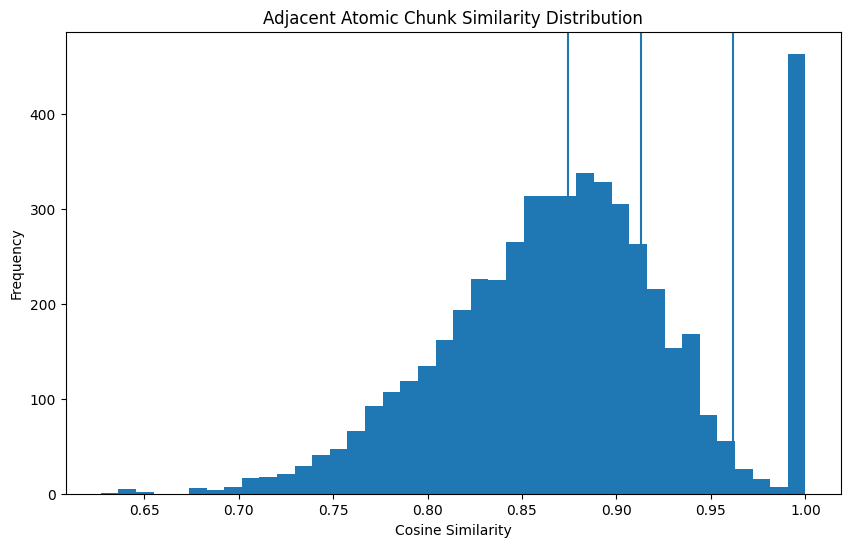


Suggested threshold candidates:
Balanced (p50-p75 zone): 0.8935
Conservative merge (p75): 0.9128
Very strict (p90): 0.9618


In [ ]:
pdf_paths = glob(os.path.join(PDF_DIR, "*.pdf"))
similarities = []

for pdf_path in tqdm(pdf_paths):
    doc = converter.convert(pdf_path).document
    raw_text = extract_full_text_from_doc(doc)
    
    if not raw_text:
        continue
    
    encoding = tokenizer(
        [raw_text],
        truncation=True,
        max_length=ATOMIC_TOKEN_SIZE,
        return_overflowing_tokens=True,
        stride=0,
        add_special_tokens=False
    )

    chunks_input_ids = encoding["input_ids"]

    prev_emb = None

    for input_ids in chunks_input_ids:
        if len(input_ids) == 0:
            continue

        emb = embedder.encode_ids(input_ids)

        if prev_emb is not None:
            sim = cosine_sim(prev_emb, emb)
            similarities.append(sim)

        prev_emb = emb


similarities = np.array(similarities)


# ==========================================
# 5️⃣ Percentile stats
# ==========================================
p25 = np.percentile(similarities, 25)
p50 = np.percentile(similarities, 50)
p75 = np.percentile(similarities, 75)
p90 = np.percentile(similarities, 90)

print("\nSimilarity Percentiles")
print(f"P25: {p25:.4f}")
print(f"P50: {p50:.4f}")
print(f"P75: {p75:.4f}")
print(f"P90: {p90:.4f}")


# ==========================================
# 6️⃣ Plot histogram
# ==========================================
plt.figure(figsize=(10, 6))
plt.hist(similarities, bins=40)

plt.axvline(p50)
plt.axvline(p75)
plt.axvline(p90)

plt.title("Adjacent Atomic Chunk Similarity Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")

plt.show()


# ==========================================
# 7️⃣ Suggested threshold
# ==========================================
print("\nSuggested threshold candidates:")
print(f"Balanced (p50-p75 zone): {((p50 + p75)/2):.4f}")
print(f"Conservative merge (p75): {p75:.4f}")
print(f"Very strict (p90): {p90:.4f}")

In [2]:
query = "What are WHO recommendations for physical activity for children under 5?"
contexts = retrieve_context(query=query, top_k=TOP_K, strategy="structure")

2026-02-28 09:41:38,333 - INFO - Use pytorch device_name: cpu
2026-02-28 09:41:38,335 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2
2026-02-28 09:41:44,457 - INFO - Anonymized telemetry enabled. See                     https://docs.trychroma.com/telemetry for more information.
F:\customer_support_rag_chatbot\src\retriever.py:91: LangChainDeprecationWarning: The method `BaseRetriever.get_relevant_documents` was deprecated in langchain-core 0.1.46 and will be removed in 1.0. Use :meth:`~invoke` instead.
  vector_docs = vector_retriever.get_relevant_documents(query)
2026-02-28 09:41:49,685 - INFO - Use pytorch device_name: cpu
2026-02-28 09:41:49,687 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2


In [3]:
print(contexts[0])
print(contexts[1])

source_id='global_recommendations_on_physical_activity_for_health' content='4.5 FUTURE REVIEw OF REcOmmENdATIONS ANd RESEARcH gAPS\n- 1) Sedentary behaviour contributing to disease risk profile.\n- 2) Health-enhancing physical activity in children under 5 years old.\n- 3) Health-enhancing physical activity in pregnant women.\n- 4) Physical activity and disabilities.\n- 5) Weight loss or maintenance of weight loss.\n- 6) Physical activity doses for the clinical treatment of people with an NCD (e.g. cardiovascular disease, diabetes, cancer, obesity, mental health conditions, etc.).\nGlobal Recommendations on Physical Activity for Health\n35' section_path=['4.5 FUTURE REVIEw OF REcOmmENdATIONS ANd RESEARcH gAPS'] page_numbers=[] chunk_indices=[36] score=None dataset=None
source_id='who_guidelines_on_physical_activity_and_sedentary_behaviour' content='PHYSICAL ACTIVITY RECOMMENDATION\nFor children and adolescents, physical activity can be undertaken as part of recreation and leisure (play,

In [20]:
model_path = "./models/all-MiniLM-L6-v2"

model = SentenceTransformer(model_path, local_files_only=True)

@lru_cache(maxsize=10000)
def embed_text(text: str):
    return model.encode(text)

# =========================
# Metrics
# =========================

def recall_at_k(retrieved_docs, relevant_docs):
    retrieved_set = set(retrieved_docs)
    relevant_set = set(relevant_docs)
   
    return len(retrieved_set & relevant_set) / len(relevant_set)

def hit_rate(retrieved_docs, relevant_docs):
    return int(len(set(retrieved_docs) & set(relevant_docs)) > 0)

def answer_containment(contexts, expected_spans):
    context_text = " ".join(contexts)
    for span in expected_spans:
        if span.lower() in context_text:
            return 1
        
    return 0

def reciprocal_rank(retrieved_docs, relevant_docs):
    for i, doc in enumerate(retrieved_docs):
        if doc in relevant_docs:
            return 1 / (i + 1)
        
    return 0

def context_precision(retrieved_docs, relevant_docs):
    return len(set(retrieved_docs) & set(relevant_docs)) / len(retrieved_docs)

def redundancy_score(context_texts):
    if len(context_texts) <= 1:
        return 0.0

    embeddings = np.array([embed_text(t) for t in context_texts])
    embeddings = torch.tensor(embeddings)
    embeddings = F.normalize(embeddings, dim=1)
    
    sim_matrix = F.cosine_similarity(
        embeddings.unsqueeze(1),
        embeddings.unsqueeze(0),
        dim=-1
    )

    mask = ~torch.eye(len(context_texts), dtype=torch.bool)
    sims = sim_matrix[mask]

    return sims.mean().item()

2026-02-28 15:57:29,669 - INFO - Use pytorch device_name: cpu
2026-02-28 15:57:29,672 - INFO - Load pretrained SentenceTransformer: ./models/all-MiniLM-L6-v2


In [23]:
from collections import defaultdict

# ===== Load dataset =====
with open("../data/evaluation/retrieval_evaluation.json", "r", encoding="utf-8") as f:
    dataset = json.load(f)

# =========================
# Evaluation Loop
# =========================

strategies = [
    "structure",
    "sliding",
    "semantic",
    "hybrid_section_semantic"
]

all_results = defaultdict(list)

for strategy in strategies:
    print(f"\n🔍 Evaluating strategy: {strategy}")

    for sample in tqdm(dataset):
        query = sample["question"]
        relevant_docs = sample["relevant_documents"]
        expected_spans = sample["expected_answer_span"]

        contexts = retrieve_context(
            query=query,
            top_k=TOP_K,
            strategy=strategy
        )

        retrieved_docs = [ctx.source_id for ctx in contexts]
        retrieved_texts = [ctx.content for ctx in contexts]
        
        print("RELEVANT:", sample["relevant_documents"])
        print("RETRIEVED:", retrieved_docs[:5])
        
        break

        # Metrics
        r = recall_at_k(retrieved_docs, relevant_docs)
        hit = hit_rate(retrieved_docs, relevant_docs)
        rr = reciprocal_rank(retrieved_docs, relevant_docs)
        ans = answer_containment(retrieved_texts, expected_spans)
        prec = context_precision(retrieved_docs, relevant_docs)
        red = redundancy_score(retrieved_texts)

        all_results[strategy].append({
            "recall": r,
            "hit": hit,
            "mrr": rr,
            "answer": ans,
            "precision": prec,
            "redundancy": red
        })


🔍 Evaluating strategy: structure


  0%|          | 0/20 [00:00<?, ?it/s]2026-02-28 16:54:52,649 - INFO - Use pytorch device_name: cpu
2026-02-28 16:54:52,652 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2
  0%|          | 0/20 [00:08<?, ?it/s]


RELEVANT: ['WHO GUIDELINES ON PHYSICAL ACTIVITY AND SEDENTARY BEHAVIOUR.pdf', 'Global recommendations on physical activity for health.pdf']
RETRIEVED: ['who_guidelines_on_physical_activity_and_sedentary_behaviour', 'who_guidelines_on_physical_activity_and_sedentary_behaviour', 'global_recommendations_on_physical_activity_for_health', 'global_recommendations_on_physical_activity_for_health', 'global_recommendations_on_physical_activity_for_health']

🔍 Evaluating strategy: sliding


  0%|          | 0/20 [00:00<?, ?it/s]2026-02-28 16:55:01,239 - INFO - Use pytorch device_name: cpu
2026-02-28 16:55:01,248 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2
  0%|          | 0/20 [00:04<?, ?it/s]


RELEVANT: ['WHO GUIDELINES ON PHYSICAL ACTIVITY AND SEDENTARY BEHAVIOUR.pdf', 'Global recommendations on physical activity for health.pdf']
RETRIEVED: ['global_recommendations_on_physical_activity_for_health', 'risk_reduction_of_cognitive_decline_and_dementia', 'who_guidelines_on_physical_activity_and_sedentary_behaviour', 'who_guidelines_on_physical_activity_and_sedentary_behaviour', 'who_guidelines_on_physical_activity_and_sedentary_behaviour']

🔍 Evaluating strategy: semantic


  0%|          | 0/20 [00:00<?, ?it/s]2026-02-28 16:55:05,982 - INFO - Use pytorch device_name: cpu
2026-02-28 16:55:05,991 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2
  0%|          | 0/20 [00:04<?, ?it/s]


RELEVANT: ['WHO GUIDELINES ON PHYSICAL ACTIVITY AND SEDENTARY BEHAVIOUR.pdf', 'Global recommendations on physical activity for health.pdf']
RETRIEVED: ['global_recommendations_on_physical_activity_for_health', 'who_guidelines_on_physical_activity_and_sedentary_behaviour', 'who_guidelines_on_physical_activity_and_sedentary_behaviour', 'who_guidelines_on_physical_activity_and_sedentary_behaviour', 'risk_reduction_of_cognitive_decline_and_dementia']

🔍 Evaluating strategy: hybrid_section_semantic


  0%|          | 0/20 [00:00<?, ?it/s]2026-02-28 16:55:10,848 - INFO - Use pytorch device_name: cpu
2026-02-28 16:55:10,898 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2
  0%|          | 0/20 [00:06<?, ?it/s]

RELEVANT: ['WHO GUIDELINES ON PHYSICAL ACTIVITY AND SEDENTARY BEHAVIOUR.pdf', 'Global recommendations on physical activity for health.pdf']
RETRIEVED: ['who_guidelines_on_physical_activity_and_sedentary_behaviour', 'who_guidelines_on_physical_activity_and_sedentary_behaviour', 'global_recommendations_on_physical_activity_for_health', 'global_recommendations_on_physical_activity_for_health', 'global_recommendations_on_physical_activity_for_health']


In [22]:
# =========================
# Aggregate Results
# =========================

def aggregate(results):
    return {
        "Recall@K": np.mean([r["recall"] for r in results]),
        "Hit@K": np.mean([r["hit"] for r in results]),
        "MRR": np.mean([r["mrr"] for r in results]),
        "AnswerContainment": np.mean([r["answer"] for r in results]),
        "ContextPrecision": np.mean([r["precision"] for r in results]),
        "Redundancy": np.mean([r["redundancy"] for r in results]),
    }


summary = {}

for strategy in strategies:
    summary[strategy] = aggregate(all_results[strategy])


# =========================
# Print Results
# =========================

df = pd.DataFrame(summary).T
df = df.sort_values(by="AnswerContainment", ascending=False)

print("\n📊 Final Comparison:")
display(df)


📊 Final Comparison:


,Recall@K,Hit@K,MRR,AnswerContainment,ContextPrecision,Redundancy
sliding,0.0,0.0,0.0,0.3,0.0,0.502565
structure,0.0,0.0,0.0,0.2,0.0,0.489006
semantic,0.0,0.0,0.0,0.2,0.0,0.498523
hybrid_section_semantic,0.0,0.0,0.0,0.2,0.0,0.489006
